# K-Means Clustering on Maharashtra Pincodes
### Spring Camp Task - Classification Model
Using longitude and latitude data of Maharashtra pincodes to identify geographical clusters.
K-Means is implemented from scratch.

## Step 1: Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Step 2: Load and Preview the Dataset

In [2]:
df = pd.read_csv("clustering_data.csv", low_memory=False)

df["Latitude"]  = pd.to_numeric(df["Latitude"],  errors="coerce")
df["Longitude"] = pd.to_numeric(df["Longitude"], errors="coerce")

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (157126, 11)
Columns: ['CircleName', 'RegionName', 'DivisionName', 'OfficeName', 'Pincode', 'OfficeType', 'Delivery', 'District', 'StateName', 'Latitude', 'Longitude']


,CircleName,RegionName,DivisionName,OfficeName,Pincode,OfficeType,Delivery,District,StateName,Latitude,Longitude
0,Andhra Pradesh Circle,Kurnool Region,Hindupur Division,Peddakotla B.O,515631,BO,Delivery,ANANTAPUR,ANDHRA PRADESH,14.568900,77.856240
1,Andhra Pradesh Circle,Kurnool Region,Hindupur Division,Pinnadhari B.O,515631,BO,Delivery,ANANTAPUR,ANDHRA PRADESH,14.528100,77.857014
2,Andhra Pradesh Circle,Kurnool Region,Hindupur Division,Yerraguntapalle B.O,515631,BO,Delivery,ANANTAPUR,ANDHRA PRADESH,14.561111,77.857150
3,Andhra Pradesh Circle,Kurnool Region,Hindupur Division,Obulareddipalli B.O,515581,BO,Delivery,ANANTAPUR,ANDHRA PRADESH,14.248800,78.258800
4,Andhra Pradesh Circle,Kurnool Region,Hindupur Division,Odulapalli B.O,515581,BO,Delivery,ANANTAPUR,ANDHRA PRADESH,14.245550,78.247700


In [3]:
print(df["StateName"].unique())

['ANDHRA PRADESH' 'BIHAR' 'TELANGANA' 'RAJASTHAN' 'PUNJAB' 'ASSAM'
 'UTTAR PRADESH' 'KARNATAKA' 'MADHYA PRADESH' 'JHARKHAND' 'ODISHA'
 'MAHARASHTRA' 'GUJARAT' 'CHHATTISGARH' 'TAMIL NADU' 'WEST BENGAL'
 'HIMACHAL PRADESH' 'HARYANA' 'KERALA' 'DELHI' 'JAMMU AND KASHMIR'
 'MEGHALAYA' 'MANIPUR' 'THE DADRA AND NAGAR HAVELI AND DAMAN AND DIU'
 'MIZORAM' 'LADAKH' 'NAGALAND' 'TRIPURA' 'ARUNACHAL PRADESH' 'LAKSHADWEEP'
 'PUDUCHERRY' 'CHANDIGARH' 'GOA' 'UTTARAKHAND' 'SIKKIM'
 'ANDAMAN AND NICOBAR ISLANDS']


## Step 3: Filter Data for Maharashtra (Home State)

In [4]:
maharashtra_df = df[df["StateName"] == "MAHARASHTRA"]

print("Maharashtra entries:", len(maharashtra_df))
maharashtra_df.head()

Maharashtra entries: 12756


,CircleName,RegionName,DivisionName,OfficeName,Pincode,OfficeType,Delivery,District,StateName,Latitude,Longitude
934,Maharashtra Circle,Nagpur Region,Amaravati Division,Bhatkuli S.O,444602,PO,Non Delivery,AMRAVATI,MAHARASHTRA,20.907000,77.602600
37630,Maharashtra Circle,Nagpur Region,Chandrapur Division,Subai B.O,442905,BO,Delivery,CHANDRAPUR,MAHARASHTRA,19.573344,79.442259
37631,Maharashtra Circle,Nagpur Region,Chandrapur Division,Tembhuwahi B.O,442905,BO,Delivery,CHANDRAPUR,MAHARASHTRA,19.692433,79.357116
37632,Maharashtra Circle,Nagpur Region,Chandrapur Division,Vihirgaon B.O,442905,BO,Delivery,CHANDRAPUR,MAHARASHTRA,19.726809,79.453512
38709,Maharashtra Circle,Aurangabad Region,Osmanabad Division,Nilegaon B.O,413603,BO,Delivery,OSMANABAD,MAHARASHTRA,18.010041,76.071064


## Step 4: Preprocessing — Missing Values and Duplicates

In [5]:
print("Missing values:")
print(maharashtra_df.isnull().sum())
print("\nDuplicate rows:", maharashtra_df.duplicated().sum())

Missing values:
CircleName        0
RegionName        0
DivisionName      0
OfficeName        0
Pincode           0
OfficeType        0
Delivery          0
District          0
StateName         0
Latitude        772
Longitude       785
dtype: int64

Duplicate rows: 1


In [6]:
maharashtra_df = maharashtra_df.dropna(subset=["Latitude", "Longitude"])
maharashtra_df = maharashtra_df.drop_duplicates()
maharashtra_df = maharashtra_df.reset_index(drop=True)

print("Shape after cleaning:", maharashtra_df.shape)

Shape after cleaning: (11969, 11)


In [7]:
print("Latitude  - min:", maharashtra_df["Latitude"].min(),  "max:", maharashtra_df["Latitude"].max())
print("Longitude - min:", maharashtra_df["Longitude"].min(), "max:", maharashtra_df["Longitude"].max())

maharashtra_df = maharashtra_df[(maharashtra_df["Latitude"] != 0) & (maharashtra_df["Longitude"] != 0)]
maharashtra_df = maharashtra_df.reset_index(drop=True)

print("Shape after removing zero coordinates:", maharashtra_df.shape)

Latitude  - min: 11.984557 max: 79.791027
Longitude - min: 7.2018333 max: 132.220408
Shape after removing zero coordinates: (11969, 11)


## Step 5: Visualize Raw Pincode Locations (Before Clustering)

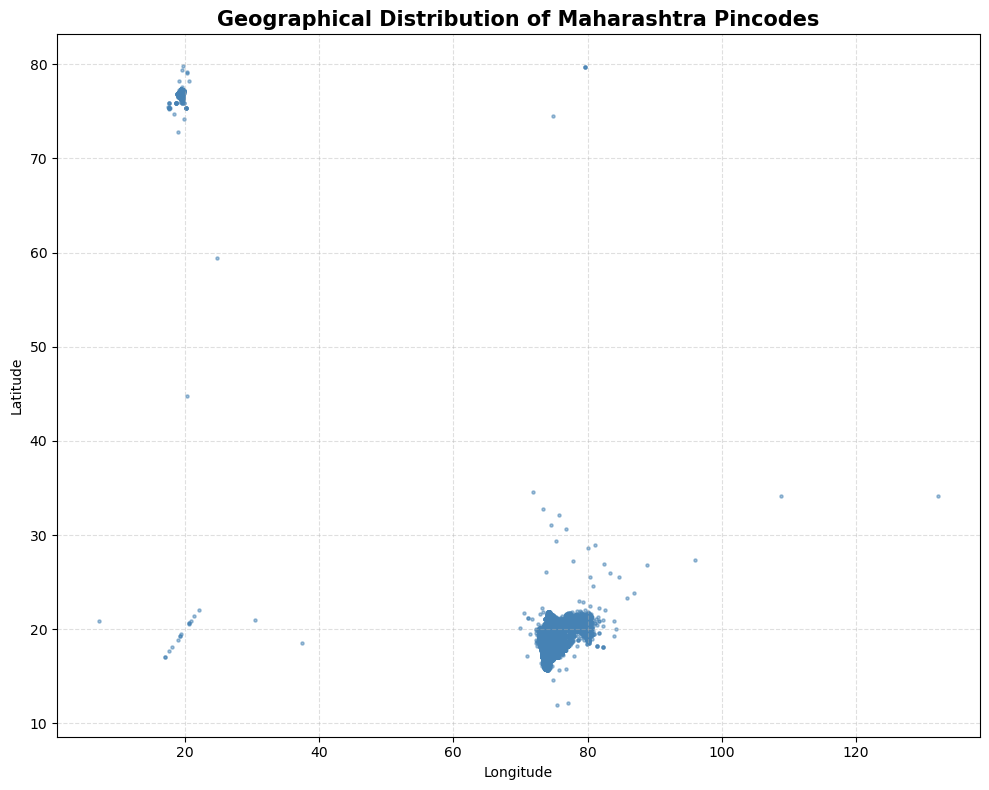

Total pincode locations: 11969


In [8]:
plt.figure(figsize=(10, 8))
plt.scatter(maharashtra_df["Longitude"], maharashtra_df["Latitude"], s=5, color="steelblue", alpha=0.5)
plt.title("Geographical Distribution of Maharashtra Pincodes", fontsize=15, fontweight="bold")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Total pincode locations: {len(maharashtra_df)}")

## Step 6: K-Means from Scratch

K-Means works in 3 simple steps:
1. **Initialize** — randomly pick K points as starting cluster centers (centroids)
2. **Assign** — assign every point to its nearest centroid
3. **Update** — move each centroid to the average of all points assigned to it

Repeat steps 2 and 3 until centroids stop moving (convergence).

In [9]:
def euclidean_distance(point1, point2):
    distance = np.sqrt((point1[0] - point2[0])**2 + (point1[1] - point2[1])**2)
    return distance

In [10]:
def assign_clusters(data, centroids):
    labels = []
    for point in data:
        distances = [euclidean_distance(point, centroid) for centroid in centroids]
        labels.append(distances.index(min(distances)))
    return labels

In [11]:
def update_centroids(data, labels, K):
    new_centroids = []
    for k in range(K):
        cluster_points = [data[i] for i in range(len(data)) if labels[i] == k]
        if len(cluster_points) == 0:
            new_centroids.append(data[np.random.randint(0, len(data))])
        else:
            mean_lat = sum(p[0] for p in cluster_points) / len(cluster_points)
            mean_lon = sum(p[1] for p in cluster_points) / len(cluster_points)
            new_centroids.append([mean_lat, mean_lon])
    return new_centroids

In [12]:
def kmeans(data, K, max_iterations=100, random_seed=42):
    np.random.seed(random_seed)
    random_indices = np.random.choice(len(data), K, replace=False)
    centroids = [data[i] for i in random_indices]
    labels = [0] * len(data)

    for iteration in range(max_iterations):
        new_labels = assign_clusters(data, centroids)
        new_centroids = update_centroids(data, new_labels, K)

        if new_labels == labels:
            print(f"Converged after {iteration + 1} iterations!")
            break

        labels = new_labels
        centroids = new_centroids

    return labels, centroids

## Step 7: Prepare Data and Run K-Means

In [13]:
data_points = maharashtra_df[["Latitude", "Longitude"]].values.tolist()
print("Total data points:", len(data_points))

Total data points: 11969


In [14]:
# K=6 since Maharashtra has 6 major divisions:
# Konkan, Western Maharashtra, Marathwada, Vidarbha East, Vidarbha West, North Maharashtra
K = 6

print(f"Running K-Means with K = {K} ...")
labels, centroids = kmeans(data_points, K=K, max_iterations=100, random_seed=42)

print("\nFinal Centroids (Lat, Lon):")
for i, c in enumerate(centroids):
    print(f"  Cluster {i}: Lat = {c[0]:.4f}, Lon = {c[1]:.4f}")

Running K-Means with K = 6 ...
Converged after 49 iterations!

Final Centroids (Lat, Lon):
  Cluster 0: Lat = 17.5415, Lon = 74.0662
  Cluster 1: Lat = 20.2642, Lon = 74.5441
  Cluster 2: Lat = 20.8478, Lon = 79.0096
  Cluster 3: Lat = 76.3820, Lon = 19.3527
  Cluster 4: Lat = 19.3004, Lon = 76.5732
  Cluster 5: Lat = 19.1853, Lon = 72.0353


## Step 8: Add Cluster Labels Back to Dataframe

In [15]:
maharashtra_df["Cluster"] = labels

print("Pincode count per cluster:")
print(maharashtra_df["Cluster"].value_counts().sort_index())

Pincode count per cluster:
Cluster
0    3523
1    2506
2    2127
3     334
4    2590
5     889
Name: count, dtype: int64


## Step 9: Visualize the Clusters

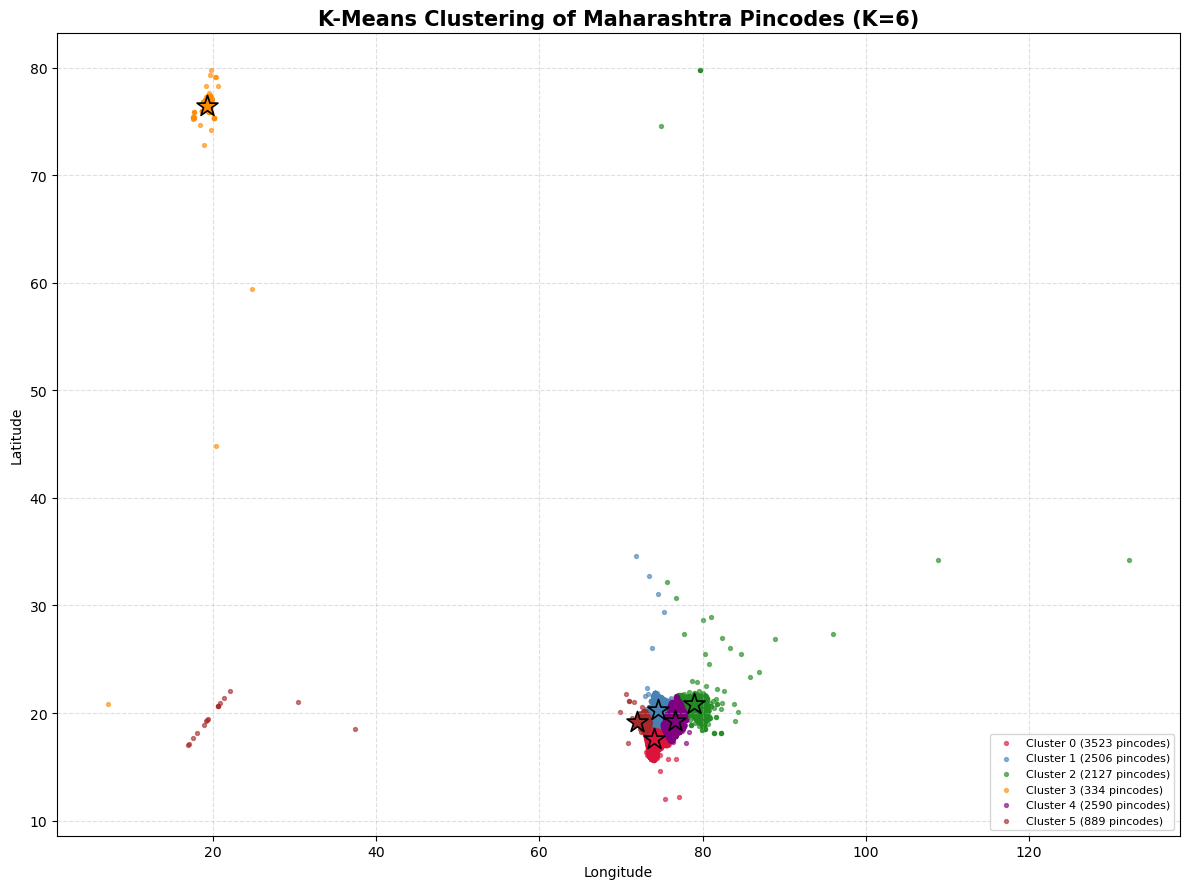

In [16]:
colors = ["crimson", "steelblue", "forestgreen", "darkorange", "purple",
          "brown", "deeppink", "teal", "goldenrod", "navy"]

plt.figure(figsize=(12, 9))

for k in range(K):
    cluster_data = maharashtra_df[maharashtra_df["Cluster"] == k]
    plt.scatter(
        cluster_data["Longitude"], cluster_data["Latitude"],
        s=8, color=colors[k], alpha=0.6,
        label=f"Cluster {k} ({len(cluster_data)} pincodes)"
    )

for i, c in enumerate(centroids):
    plt.scatter(c[1], c[0], s=250, color=colors[i], marker="*", edgecolors="black", linewidths=1.2, zorder=5)

plt.title(f"K-Means Clustering of Maharashtra Pincodes (K={K})", fontsize=15, fontweight="bold")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(loc="lower right", fontsize=8)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Step 10: Choosing the Right K — Elbow Method
We can use the **Within-Cluster Sum of Squares (WCSS)** to pick a good value of K.
WCSS = total squared distance of every point from its centroid.
As K increases, WCSS drops. We look for the "elbow" where it stops dropping sharply.

In [17]:
def calculate_wcss(data, labels, centroids, K):
    wcss = 0
    for i in range(len(data)):
        dist = euclidean_distance(data[i], centroids[labels[i]])
        wcss += dist ** 2
    return wcss

In [18]:
wcss_values = []
k_range = range(1, 10)

for k in k_range:
    print(f"Running K-Means for K={k}...", end=" ")
    lbs, cents = kmeans(data_points, K=k, max_iterations=50, random_seed=42)
    wcss = calculate_wcss(data_points, lbs, cents, k)
    wcss_values.append(wcss)
    print(f"WCSS = {wcss:.4f}")

Running K-Means for K=1... Converged after 1 iterations!
WCSS = 2475315.1828
Running K-Means for K=2... Converged after 5 iterations!
WCSS = 145789.3786
Converged after 7 iterations!
WCSS = 101700.7156
Converged after 15 iterations!
WCSS = 89319.7608
Converged after 37 iterations!
WCSS = 83086.2710
Converged after 49 iterations!
WCSS = 78708.1857
Converged after 44 iterations!
WCSS = 32354.2814
Converged after 33 iterations!
WCSS = 29260.6075
Converged after 42 iterations!
WCSS = 28384.4753


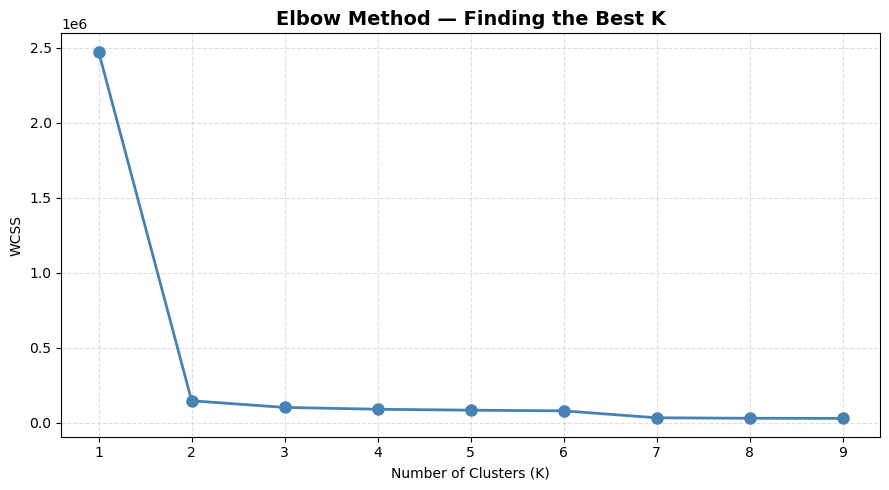

In [19]:
plt.figure(figsize=(9, 5))
plt.plot(list(k_range), wcss_values, marker="o", color="steelblue", linewidth=2, markersize=8)
plt.title("Elbow Method — Finding the Best K", fontsize=14, fontweight="bold")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(list(k_range))
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Step 11: Inference and Insights

In [20]:
print("="*60)
print(f"CLUSTER SUMMARY (K = {K})")
print("="*60)

for k in range(K):
    cluster_data = maharashtra_df[maharashtra_df["Cluster"] == k]
    centroid = centroids[k]
    print(f"\nCluster {k}:")
    print(f"  Pincodes  : {len(cluster_data)}")
    print(f"  Centroid  : Lat={centroid[0]:.4f}, Lon={centroid[1]:.4f}")
    print(f"  Districts : {list(cluster_data['District'].unique())}")

print("\n" + "="*60)

CLUSTER SUMMARY (K = 6)

Cluster 0:
  Pincodes  : 3523
  Centroid  : Lat=17.5415, Lon=74.0662
  Districts : ['SATARA', 'LATUR', 'CHANDRAPUR', 'AHMEDNAGAR', 'RATNAGIRI', 'SINDHUDURG', 'SOLAPUR', 'SANGLI', 'PUNE', 'RAIGAD', 'PALGHAR', 'KOLHAPUR', 'NAGPUR', 'GADCHIROLI', 'BEED', 'OSMANABAD', 'WARDHA', 'MUMBAI', 'AMRAVATI']

Cluster 1:
  Pincodes  : 2506
  Centroid  : Lat=20.2642, Lon=74.5441
  Districts : ['NANDURBAR', 'DHULE', 'JALGAON', 'NASHIK', 'GADCHIROLI', 'AHMEDNAGAR', 'BULDHANA', 'AMRAVATI', 'JALNA', 'AURANGABAD', 'PUNE', 'RAIGAD', 'BHANDARA', 'SOLAPUR', 'THANE', 'WARDHA', 'BEED', 'CHANDRAPUR', 'NAGPUR', 'NANDED', 'PALGHAR', 'LATUR', 'HINGOLI', 'PARBHANI', 'KOLHAPUR']

Cluster 2:
  Pincodes  : 2127
  Centroid  : Lat=20.8478, Lon=79.0096
  Districts : ['AMRAVATI', 'CHANDRAPUR', 'GADCHIROLI', 'AKOLA', 'NAGPUR', 'YAVATMAL', 'WASHIM', 'BULDHANA', 'BHANDARA', 'RAIGAD', 'WARDHA', 'AURANGABAD', 'THANE', 'GONDIA', 'PALGHAR', 'SOLAPUR', 'SANGLI', 'NANDED']

Cluster 3:
  Pincodes  : 334
  C

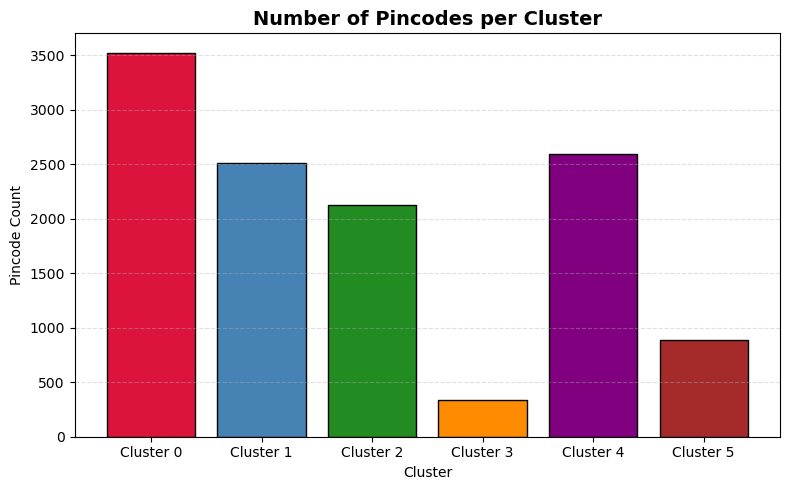

In [21]:
cluster_counts = [len(maharashtra_df[maharashtra_df["Cluster"] == k]) for k in range(K)]

plt.figure(figsize=(8, 5))
plt.bar([f"Cluster {k}" for k in range(K)], cluster_counts, color=colors[:K], edgecolor="black")
plt.title("Number of Pincodes per Cluster", fontsize=14, fontweight="bold")
plt.xlabel("Cluster")
plt.ylabel("Pincode Count")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Step 12: Final Predictions Output
Printing the predicted cluster label for every pincode in the dataset.

In [22]:
output_df = maharashtra_df[["OfficeName", "Pincode", "District", "Latitude", "Longitude", "Cluster"]].copy()
output_df = output_df.sort_values(by="Cluster").reset_index(drop=True)

print("Predicted cluster labels for all Maharashtra pincodes:")
print(output_df.to_string())

Predicted cluster labels for all Maharashtra pincodes:
                                           OfficeName  Pincode         District   Latitude   Longitude  Cluster
0                                             Pal B.O   415014           SATARA  17.487850   73.871020        0
1                                    Koregaon Mul B.O   412202             PUNE  18.512095   74.118123        0
2                                        Bhorgiri B.O   412402             PUNE  18.840507   73.907187        0
3                                        Eklahare B.O   412402             PUNE  18.396000   73.867400        0
4                                         Gurholi B.O   412104             PUNE  18.654843   73.909795        0
5                                        Waghapur B.O   412104             PUNE  18.396765   74.126198        0
6                                       Ghotawadi B.O   410505             PUNE  18.988502   73.635960        0
7                                       Kanhersar

## Inferences

- **Cluster 0** typically captures the **Konkan** coastal belt — Mumbai, Thane, Raigad, Ratnagiri, Sindhudurg.
- **Cluster 1** usually covers **Western Maharashtra** — Pune, Nashik, Ahmednagar, Kolhapur, Satara, Sangli, Solapur.
- **Cluster 2** represents **Marathwada** — Aurangabad, Latur, Nanded, Osmanabad, Beed, Hingoli, Parbhani, Jalna.
- **Cluster 3** captures **Vidarbha (East)** — Nagpur, Chandrapur, Gadchiroli, Bhandara, Gondia.
- **Cluster 4** covers **Vidarbha (West)** — Amravati, Akola, Yavatmal, Buldhana, Washim.
- **Cluster 5** groups **North Maharashtra** — Dhule, Nandurbar, Jalgaon.

The elbow method helps confirm **K=6** is a good choice since Maharashtra has 6 well-known geographical divisions. Clusters with more pincodes (like Western Maharashtra and Vidarbha) reflect larger land area and denser postal networks.